## Dependency Installation

In [ ]:
! pip install pypots==v0.18

In [695]:
import pypots
import os


In [885]:
import pandas as pd
import numpy as np
import logging
from types import SimpleNamespace

# simple logger (to keep your logger.info line working)
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("preprocess")

# mimic argparse args with your two paths
args = SimpleNamespace(
    ground_truth_path=r"outputs\preprocessed\sepsis_merged.csv",
    missing_data_path=r"outputs\preprocessed\sepsis_merged_miss_start_date_15.csv",
)


In [886]:
# Load datasets
df_ground = pd.read_csv(args.ground_truth_path)
df_missing = pd.read_csv(args.missing_data_path)

# --- preserve file order + define per-case step index ---
for df in (df_ground, df_missing):
    df["_row"] = np.arange(len(df))                      # global row id (file order)
    df["case_event_idx"] = df.groupby("case_id").cumcount()  # 0.. within each case, in file order
    
# Print number of samples
num_samples_ground = len(df_ground)
logger.info(f"Total samples in ground truth: {num_samples_ground}")

# Print missing value counts
missing_in_ground = df_ground["start_date"].isna().sum()
missing_in_missing = df_missing["start_date"].isna().sum()
print(f"Missing start_date in ground truth: {missing_in_ground}")
print(f"Missing start_date in missing data file: {missing_in_missing}")


INFO:preprocess:Total samples in ground truth: 15207


Missing start_date in ground truth: 0
Missing start_date in missing data file: 1966


In [887]:
def normalize_case_id(df):
    # keep strings, trim spaces
    s = df["case_id"].astype("string").str.strip()
    # treat blank as the literal ID "NA" (your special case)
    s = s.mask(s.eq("") | s.isna(), "NA")
    df["case_id"] = s
    return df

df_ground  = normalize_case_id(df_ground)
df_missing = normalize_case_id(df_missing)

In [888]:
def parse_dt(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce", utc=True)
    return df


def add_safe_features(df):
    # Sort for stable case-history features (SAFE: uses only create_date ordering)
    df = df.sort_values(["case_id", "create_date"]).reset_index(drop=True)

    # Case history based only on create_date
    df["case_event_idx"] = df.groupby("case_id").cumcount().astype(float)
    case_start_create = df.groupby("case_id")["create_date"].transform("min")
    df["sec_since_case_start_create"] = (df["create_date"] - case_start_create).dt.total_seconds().astype(float)

    df["prev_same_task_count"] = df.groupby(["case_id", "task"]).cumcount().astype(float)

    # Calendar features from create_date (SAFE)
    df["create_hour"]  = df["create_date"].dt.hour.astype(float)
    df["create_dow"]   = df["create_date"].dt.dayofweek.astype(float)


    return df

def recompute_durations(df):

    # Processing duration: complete - start (this is what we will model)
    df["processing_duration_sec"] = (df["complete_date"] - df["start_date"]).dt.total_seconds()

    # Optional: start lag from create (sometimes useful to inspect)
    df["start_lag_sec"] = (df["start_date"] - df["create_date"]).dt.total_seconds()

    # End-to-end observed duration available even when start is missing
    df["total_duration"] = (df["case_complete_date"] - df["create_date"]).dt.total_seconds()

    return df

In [889]:
# --- Parse dates ---
dt_cols = ["create_date", "start_date", "complete_date", "case_complete_date"]
df_ground  = parse_dt(df_ground, dt_cols)
df_missing = parse_dt(df_missing, dt_cols)

# --- Add SAFE engineered features (create-only history) ---
df_ground  = add_safe_features(df_ground)
df_missing = add_safe_features(df_missing)

# --- Recompute durations from dates ---
df_ground  = recompute_durations(df_ground)
df_missing = recompute_durations(df_missing)  # proc_dur_sec will be NaN where start_date is NaN

# --- Sanity cleaning for training target ---
train_mask = (
    df_ground["start_date"].notna() &
    df_ground["complete_date"].notna() &
    df_ground["create_date"].notna()
)

In [890]:
# duration must be >= 0 (bad logs can exist)
df_ground.loc[train_mask, "processing_duration_sec"] = df_ground.loc[train_mask, "processing_duration_sec"].clip(lower=0)

print("Train rows with known start:", train_mask.sum())
print("Missing start in missing file:", df_missing["processing_duration_sec"].isna().sum())

Train rows with known start: 15207
Missing start in missing file: 1966


In [891]:
DUR_COLS = ["processing_duration_sec", "start_lag_sec", "total_duration"]  # add/remove as you like

for c in DUR_COLS:
    if c in df_ground.columns:
        df_ground[c] = df_ground[c].clip(lower=0)
        df_ground[c + "_log"] = np.log1p(df_ground[c])

    if c in df_missing.columns:
        df_missing[c] = df_missing[c].clip(lower=0)
        df_missing[c + "_log"] = np.log1p(df_missing[c])

In [892]:
df_missing[df_missing['processing_duration_sec_log'].isna()]

,case_id,task,timestamp,complete_date,create_date,start_date,case_complete_date,duration,duration_sec,total_duration,...,case_event_idx,sec_since_case_start_create,prev_same_task_count,create_hour,create_dow,processing_duration_sec,start_lag_sec,processing_duration_sec_log,start_lag_sec_log,total_duration_log
9,A,CRP,2014-10-24 09:00:00+00:00,2014-10-24 09:00:00+00:00,2014-10-22 11:15:41+00:00,NaT,2014-11-02 15:15:00+00:00,1 days 18:46:41,154001.0,964759.0,...,9.0,0.0,1.0,11.0,2.0,NaN,NaN,NaN,NaN,13.779635
15,A,CRP,2014-10-30 08:00:00+00:00,2014-10-30 08:00:00+00:00,2014-10-22 11:15:41+00:00,NaT,2014-11-02 15:15:00+00:00,2 days 00:00:00,172800.0,964759.0,...,15.0,0.0,4.0,11.0,2.0,NaN,NaN,NaN,NaN,13.779635
20,A,Leucocytes,2014-11-02 08:00:00+00:00,2014-11-02 08:00:00+00:00,2014-10-22 11:15:41+00:00,NaT,2014-11-02 15:15:00+00:00,0 days 00:00:00,1.0,964759.0,...,20.0,0.0,6.0,11.0,2.0,NaN,NaN,NaN,NaN,13.779635
36,AAA,LacticAcid,2014-11-19 03:43:00+00:00,2014-11-19 03:43:00+00:00,2014-11-19 03:16:21+00:00,NaT,2014-11-28 16:15:17+00:00,0 days 00:00:00,1.0,824336.0,...,6.0,0.0,0.0,3.0,2.0,NaN,NaN,NaN,NaN,13.622335
38,AAA,Admission NC,2014-11-19 05:44:29+00:00,2014-11-19 05:44:29+00:00,2014-11-19 03:16:21+00:00,NaT,2014-11-28 16:15:17+00:00,0 days 00:00:52,52.0,824336.0,...,8.0,0.0,0.0,3.0,2.0,NaN,NaN,NaN,NaN,13.622335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15172,ZW,CRP,2014-10-04 09:00:00+00:00,2014-10-04 09:00:00+00:00,2014-10-03 06:07:59+00:00,NaT,2014-10-07 15:00:00+00:00,0 days 21:03:48,75828.0,377521.0,...,10.0,0.0,1.0,6.0,4.0,NaN,NaN,NaN,NaN,12.841384
15176,ZX,ER Triage,2013-12-31 21:07:03+00:00,2013-12-31 21:07:03+00:00,2013-12-31 20:55:37+00:00,NaT,2014-01-05 10:00:00+00:00,0 days 00:11:26,686.0,392663.0,...,1.0,0.0,0.0,20.0,1.0,NaN,NaN,NaN,NaN,12.880710
15180,ZX,CRP,2013-12-31 21:14:00+00:00,2013-12-31 21:14:00+00:00,2013-12-31 20:55:37+00:00,NaT,2014-01-05 10:00:00+00:00,0 days 00:00:00,1.0,392663.0,...,5.0,0.0,0.0,20.0,1.0,NaN,NaN,NaN,NaN,12.880710
15181,ZX,IV Liquid,2013-12-31 23:13:30+00:00,2013-12-31 23:13:30+00:00,2013-12-31 20:55:37+00:00,NaT,2014-01-05 10:00:00+00:00,0 days 01:59:30,7170.0,392663.0,...,6.0,0.0,0.0,20.0,1.0,NaN,NaN,NaN,NaN,12.880710


In [893]:
DUR_COL = "processing_duration_sec"
KEYS = ["case_id", "case_event_idx"]


# --- 2) rows where missing has NaN but GT has value
ms_miss = df_missing[df_missing[DUR_COL].isna()][KEYS].drop_duplicates()
ms_miss

,case_id,case_event_idx
9,A,9.0
15,A,15.0
20,A,20.0
36,AAA,6.0
38,AAA,8.0
...,...,...
15172,ZW,10.0
15176,ZX,1.0
15180,ZX,5.0
15181,ZX,6.0


In [894]:
gt = df_ground.merge(ms_miss, on=KEYS, how="inner")
gt

,case_id,task,timestamp,complete_date,create_date,start_date,case_complete_date,duration,duration_sec,total_duration,...,case_event_idx,sec_since_case_start_create,prev_same_task_count,create_hour,create_dow,processing_duration_sec,start_lag_sec,processing_duration_sec_log,start_lag_sec_log,total_duration_log
0,A,CRP,2014-10-24 09:00:00+00:00,2014-10-24 09:00:00+00:00,2014-10-22 11:15:41+00:00,2014-10-22 14:13:19+00:00,2014-11-02 15:15:00+00:00,1 days 18:46:41,154001.0,964759.0,...,9.0,0.0,1.0,11.0,2.0,154001.0,10658.0,11.944721,9.274160,13.779635
1,A,CRP,2014-10-30 08:00:00+00:00,2014-10-30 08:00:00+00:00,2014-10-22 11:15:41+00:00,2014-10-28 08:00:00+00:00,2014-11-02 15:15:00+00:00,2 days 00:00:00,172800.0,964759.0,...,15.0,0.0,4.0,11.0,2.0,172800.0,506659.0,12.059896,13.135595,13.779635
2,A,Leucocytes,2014-11-02 08:00:00+00:00,2014-11-02 08:00:00+00:00,2014-10-22 11:15:41+00:00,2014-11-02 08:00:00+00:00,2014-11-02 15:15:00+00:00,0 days 00:00:00,1.0,964759.0,...,20.0,0.0,6.0,11.0,2.0,0.0,938659.0,0.000000,13.752209,13.779635
3,AAA,LacticAcid,2014-11-19 03:43:00+00:00,2014-11-19 03:43:00+00:00,2014-11-19 03:16:21+00:00,2014-11-19 03:43:00+00:00,2014-11-28 16:15:17+00:00,0 days 00:00:00,1.0,824336.0,...,6.0,0.0,0.0,3.0,2.0,0.0,1599.0,0.000000,7.377759,13.622335
4,AAA,Admission NC,2014-11-19 05:44:29+00:00,2014-11-19 05:44:29+00:00,2014-11-19 03:16:21+00:00,2014-11-19 05:43:37+00:00,2014-11-28 16:15:17+00:00,0 days 00:00:52,52.0,824336.0,...,8.0,0.0,0.0,3.0,2.0,52.0,8836.0,3.970292,9.086703,13.622335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1961,ZW,CRP,2014-10-04 09:00:00+00:00,2014-10-04 09:00:00+00:00,2014-10-03 06:07:59+00:00,2014-10-03 11:56:12+00:00,2014-10-07 15:00:00+00:00,0 days 21:03:48,75828.0,377521.0,...,10.0,0.0,1.0,6.0,4.0,75828.0,20893.0,11.236236,9.947217,12.841384
1962,ZX,ER Triage,2013-12-31 21:07:03+00:00,2013-12-31 21:07:03+00:00,2013-12-31 20:55:37+00:00,2013-12-31 20:55:37+00:00,2014-01-05 10:00:00+00:00,0 days 00:11:26,686.0,392663.0,...,1.0,0.0,0.0,20.0,1.0,686.0,0.0,6.532334,0.000000,12.880710
1963,ZX,CRP,2013-12-31 21:14:00+00:00,2013-12-31 21:14:00+00:00,2013-12-31 20:55:37+00:00,2013-12-31 21:14:00+00:00,2014-01-05 10:00:00+00:00,0 days 00:00:00,1.0,392663.0,...,5.0,0.0,0.0,20.0,1.0,0.0,1103.0,0.000000,7.006695,12.880710
1964,ZX,IV Liquid,2013-12-31 23:13:30+00:00,2013-12-31 23:13:30+00:00,2013-12-31 20:55:37+00:00,2013-12-31 21:14:00+00:00,2014-01-05 10:00:00+00:00,0 days 01:59:30,7170.0,392663.0,...,6.0,0.0,0.0,20.0,1.0,7170.0,1103.0,8.877800,7.006695,12.880710


In [895]:
# --- 3) print distribution
s = gt[DUR_COL]
h = s / 3600.0

print("Rows where df_missing duration is NaN but df_ground has value:")
print("  rows:", len(gt))
print("  unique cases:", gt["case_id"].nunique())

print("\nprocessing_duration_sec (seconds) distribution:")
print(s.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

print("\nprocessing_duration_sec (hours) distribution:")
print(h.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))


Rows where df_missing duration is NaN but df_ground has value:
  rows: 1966
  unique cases: 801

processing_duration_sec (seconds) distribution:
count      1966.000000
mean      32142.959817
std       80380.979372
min           0.000000
1%            0.000000
5%            0.000000
10%           0.000000
25%           0.000000
50%         198.500000
75%       11872.750000
90%       97200.000000
95%      176625.000000
99%      372096.400000
max      880200.000000
Name: processing_duration_sec, dtype: float64

processing_duration_sec (hours) distribution:
count    1966.000000
mean        8.928600
std        22.328050
min         0.000000
1%          0.000000
5%          0.000000
10%         0.000000
25%         0.000000
50%         0.055139
75%         3.297986
90%        27.000000
95%        49.062500
99%       103.360111
max       244.500000
Name: processing_duration_sec, dtype: float64


In [896]:
# --- 3) print distribution
s = df_ground[DUR_COL]
h = s / 3600.0

print("Rows where df_missing duration is NaN but df_ground has value:")
print("  rows:", len(df_ground))
print("  unique cases:", df_ground["case_id"].nunique())

print("\nprocessing_duration_sec (seconds) distribution:")
print(s.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

print("\nprocessing_duration_sec (hours) distribution:")
print(h.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))


Rows where df_missing duration is NaN but df_ground has value:
  rows: 15207
  unique cases: 1050

processing_duration_sec (seconds) distribution:
count    1.520700e+04
mean     1.698388e+05
std      1.443265e+06
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
10%      0.000000e+00
25%      0.000000e+00
50%      1.880000e+02
75%      1.869450e+04
90%      1.620000e+05
95%      2.592000e+05
99%      3.907818e+06
max      3.605132e+07
Name: processing_duration_sec, dtype: float64

processing_duration_sec (hours) distribution:
count    15207.000000
mean        47.177445
std        400.907058
min          0.000000
1%           0.000000
5%           0.000000
10%          0.000000
25%          0.000000
50%          0.052222
75%          5.192917
90%         45.000000
95%         72.000000
99%       1085.504989
max      10014.255000
Name: processing_duration_sec, dtype: float64


In [897]:
from sklearn.preprocessing import StandardScaler

SCALE_COLS = [
    "created_day_of_month","created_week_of_year","created_month_of_year","created_year",
    "Admission IC","Admission NC","CRP","ER Registration","ER Sepsis Triage","ER Triage",
    "IV Antibiotics","IV Liquid","LacticAcid","Leucocytes",
    "Release A","Release B","Release C","Release D","Release E","Return ER",
    "processing_duration_sec_log","total_duration_log"
]

df_for_training = df_missing[["case_id","case_event_idx", "task_encoded"] + SCALE_COLS].copy()

scaler = StandardScaler()
df_for_training[SCALE_COLS] = scaler.fit_transform(df_for_training[SCALE_COLS].astype(float))

pd.DataFrame({"feature": SCALE_COLS, "mean": scaler.mean_, "scale": scaler.scale_}) \
  .to_csv("feature_scaler.csv", index=False)


In [899]:
rng = np.random.default_rng(42)

col = "processing_duration_sec_log"
add_rate = 0.15  # 10–15% extra missing among observed rows
min_keep = 3

df_train = df_for_training.copy()
df_train[col + "_true"] = df_train[col]
df_train[col + "_mask"] = 0

# 1) observed rows (we only add missing on these)
obs = df_train[col].notna()
n_obs = int(obs.sum())
n_add = int(add_rate * n_obs)

# 2) per-case capacity (how many we are allowed to mask)
case_obs = df_train.loc[obs].groupby("case_id")[col].size()                 # observed count per case
case_cap = (case_obs - min_keep).clip(lower=0)                              # max maskable per case
total_cap = int(case_cap.sum())




In [ ]:
# rng = np.random.default_rng(42)

# col = "processing_duration_sec_log"
# add_rate = 0.15
# min_keep = 3

# df_train = df_for_training.copy()
# df_train[col + "_true"] = df_train[col]
# df_train[col + "_mask"] = 0

# # --- IMPORTANT: stable order within each case ---
# df_train = df_train.sort_values(["case_id", "case_event_idx"], kind="stable")

# # 1) observed rows
# obs = df_train[col].notna()

# # 2) protect first + last event per case (same idea as your timestamp rule)
# pos = df_train.groupby("case_id").cumcount()
# pos_rev = df_train.groupby("case_id").cumcount(ascending=False)
# protected = (pos == 0) | (pos_rev == 0)

# # 3) eligible candidates = observed AND not protected
# eligible = obs & (~protected)
# cand_idx = df_train.index[eligible].to_numpy()

# # choose how many to add
# # (use eligible count so add_rate means "fraction of eligible observed rows")
# n_add = int(round(add_rate * len(cand_idx)))
# n_add = min(n_add, len(cand_idx))

# # 4) enforce "at least min_keep observed values remain per case"
# # remaining observed count per case (before adding missing)
# remaining = df_train.loc[obs].groupby("case_id")[col].size().copy()

# # random order over candidates
# cand_idx = rng.permutation(cand_idx)

# masked = 0
# for i in cand_idx:
#     cid = df_train.at[i, "case_id"]
#     if remaining.loc[cid] <= min_keep:
#         continue  # skip: would violate min_keep
#     # apply mask
#     df_train.at[i, col] = np.nan
#     df_train.at[i, col + "_mask"] = 1
#     remaining.loc[cid] -= 1
#     masked += 1
#     if masked >= n_add:
#         break

# print(f"Eligible candidates: {len(cand_idx)}")
# print(f"Requested to mask:   {n_add}")
# print(f"Actually masked:     {masked}")


Eligible candidates: 11157
Requested to mask:   1674
Actually masked:     1674


In [900]:
# 3) global random masking with per-case min_keep constraint
obs_idx = df_train.index[obs].to_numpy()
rng.shuffle(obs_idx)

masked = 0

for i in obs_idx:
    if masked >= n_add:
        break

    cid = df_train.at[i, "case_id"]

    # how many observed values currently remain in this case?
    remain = int(df_train.loc[df_train["case_id"] == cid, col].notna().sum())

    # if masking this one would drop below min_keep, skip
    if remain <= min_keep:
        continue

    # mask it
    df_train.at[i, col] = np.nan
    df_train.at[i, col + "_mask"] = 1
    masked += 1

print("Wanted to add:", n_add)
print("Actually masked:", masked)

Wanted to add: 1986
Actually masked: 1986


In [901]:
# after masking loop

true_col = col + "_true"
mask_col = col + "_mask"

n_total = len(df_train)

# observed before (in _true)
n_obs_before = int(df_train[true_col].notna().sum())
p_obs_before = 100 * n_obs_before / n_total

# added missing (artificial)
n_added = int(df_train[mask_col].sum())
p_added_of_obs = 100 * n_added / n_obs_before if n_obs_before else 0.0
p_added_of_total = 100 * n_added / n_total

# overall missing after (in current col)
n_missing_after = int(df_train[col].isna().sum())
p_missing_after = 100 * n_missing_after / n_total

# overall missing originally (in _true)
n_missing_before = int(df_train[true_col].isna().sum())
p_missing_before = 100 * n_missing_before / n_total

print(f"Total rows: {n_total:,}")
print(f"Observed before (_true notna): {n_obs_before:,} ({p_obs_before:.2f}%)")
print(f"Original missing before (_true isna): {n_missing_before:,} ({p_missing_before:.2f}%)")

print(f"Added missing: {n_added:,} ({p_added_of_obs:.2f}% of originally observed | {p_added_of_total:.2f}% of total)")

print(f"Overall missing after (col isna): {n_missing_after:,} ({p_missing_after:.2f}%)")


Total rows: 15,207
Observed before (_true notna): 13,241 (87.07%)
Original missing before (_true isna): 1,966 (12.93%)
Added missing: 1,986 (15.00% of originally observed | 13.06% of total)
Overall missing after (col isna): 3,952 (25.99%)


In [902]:
df_full = df_train.reset_index(drop=True).copy() 

In [903]:
max_seq_length = int(df_full.groupby("case_id").size().max())
print("seq_len:", max_seq_length)

seq_len: 184


max_seq_length: 184 | max_case_id: NGA


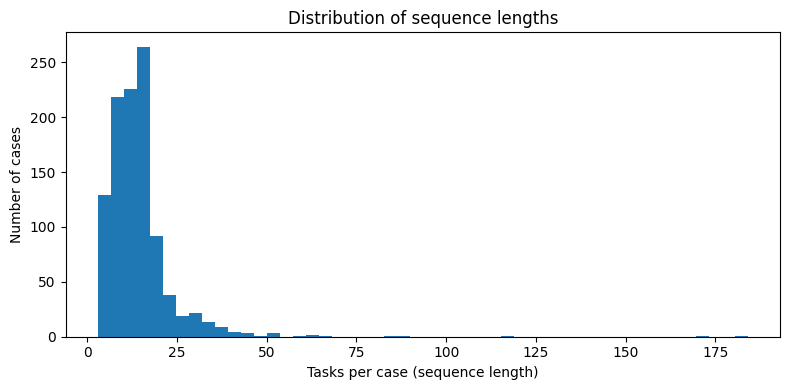

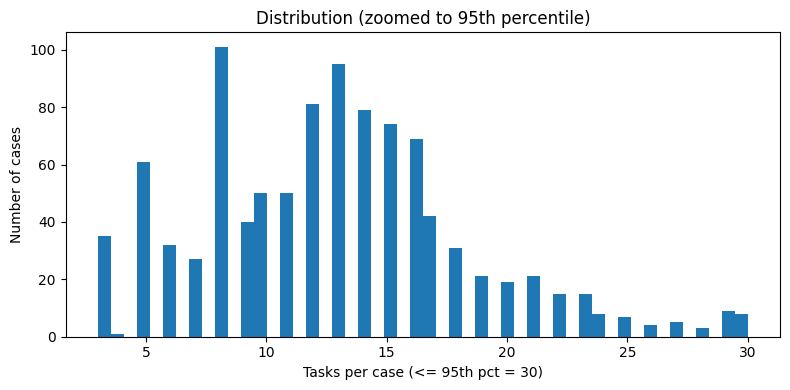

In [904]:
import matplotlib.pyplot as plt

case_sizes = df_full.groupby("case_id").size().sort_values(ascending=False)

max_seq_length = int(case_sizes.iloc[0])
max_case_id = case_sizes.index[0]
print("max_seq_length:", max_seq_length, "| max_case_id:", max_case_id)

# --- Plot 1: histogram of case lengths (full) ---
plt.figure(figsize=(8,4))
plt.hist(case_sizes.values, bins=50)
plt.xlabel("Tasks per case (sequence length)")
plt.ylabel("Number of cases")
plt.title("Distribution of sequence lengths")
plt.tight_layout()
plt.show()

# --- Plot 2: zoom to typical range (e.g., up to 95th percentile) ---
p95 = int(np.percentile(case_sizes.values, 95))
plt.figure(figsize=(8,4))
plt.hist(case_sizes[case_sizes <= p95].values, bins=50)
plt.xlabel(f"Tasks per case (<= 95th pct = {p95})")
plt.ylabel("Number of cases")
plt.title("Distribution (zoomed to 95th percentile)")
plt.tight_layout()
plt.show()


In [905]:
# 1) lengths per case
case_sizes = df_full.groupby("case_id").size().sort_values(ascending=False)

# 2) choose cap (quantile)
cap_q = 0.99
T_cap = int(case_sizes.quantile(cap_q))

print(f"Cases: {case_sizes.shape[0]}")
print(f"Max seq len: {int(case_sizes.max())}")
print(f"{int(cap_q*100)}% cap (T_cap): {T_cap}")

# 3) DROP entire cases that exceed the cap (no truncation)
drop_cases = case_sizes[case_sizes > T_cap]
n_drop_cases = int(drop_cases.shape[0])

rows_removed = int(df_full[df_full["case_id"].isin(drop_cases.index)].shape[0])
rows_total = int(case_sizes.sum())

print(f"Dropped cases: {n_drop_cases} / {case_sizes.shape[0]}")
print(f"Rows removed total: {rows_removed} / {rows_total} ({rows_removed/rows_total:.2%})")

# 4) resulting dataset (safe for splitting)
df_capped = df_full[~df_full["case_id"].isin(drop_cases.index)].copy()

print("Max len after:", int(df_capped.groupby("case_id").size().max()))
print("Remaining rows:", len(df_capped))


Cases: 1050
Max seq len: 184
99% cap (T_cap): 51
Dropped cases: 11 / 1050
Rows removed total: 995 / 15207 (6.54%)
Max len after: 51
Remaining rows: 14212


In [906]:
df_capped

,case_id,case_event_idx,task_encoded,created_day_of_month,created_week_of_year,created_month_of_year,created_year,Admission IC,Admission NC,CRP,...,Release A,Release B,Release C,Release D,Release E,Return ER,processing_duration_sec_log,total_duration_log,processing_duration_sec_log_true,processing_duration_sec_log_mask
0,A,0.0,3,0.646965,1.032315,0.965805,0.031643,-0.551038,0.363868,0.099811,...,0.616397,-0.275391,-0.202673,-0.199843,-0.096394,-0.74151,-1.087808,0.110344,-1.087808,0
1,A,1.0,9,0.646965,1.032315,0.965805,0.031643,-0.551038,0.363868,0.099811,...,0.616397,-0.275391,-0.202673,-0.199843,-0.096394,-0.74151,0.246851,0.110344,0.246851,0
2,A,2.0,2,0.646965,1.032315,0.965805,0.031643,-0.551038,0.363868,0.099811,...,0.616397,-0.275391,-0.202673,-0.199843,-0.096394,-0.74151,-1.087808,0.110344,-1.087808,0
3,A,3.0,8,0.646965,1.032315,0.965805,0.031643,-0.551038,0.363868,0.099811,...,0.616397,-0.275391,-0.202673,-0.199843,-0.096394,-0.74151,-1.087808,0.110344,-1.087808,0
4,A,4.0,5,0.646965,1.032315,0.965805,0.031643,-0.551038,0.363868,0.099811,...,0.616397,-0.275391,-0.202673,-0.199843,-0.096394,-0.74151,NaN,0.110344,0.137239,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15202,ZZ,9.0,2,-0.466152,1.225803,1.247031,0.031643,-0.551038,0.363868,0.099811,...,0.616397,-0.275391,-0.202673,-0.199843,-0.096394,-0.74151,1.313231,-0.245579,1.313231,0
15203,ZZ,10.0,9,-0.466152,1.225803,1.247031,0.031643,-0.551038,0.363868,0.099811,...,0.616397,-0.275391,-0.202673,-0.199843,-0.096394,-0.74151,NaN,-0.245579,-1.087808,1
15204,ZZ,11.0,9,-0.466152,1.225803,1.247031,0.031643,-0.551038,0.363868,0.099811,...,0.616397,-0.275391,-0.202673,-0.199843,-0.096394,-0.74151,1.380088,-0.245579,1.380088,0
15205,ZZ,12.0,2,-0.466152,1.225803,1.247031,0.031643,-0.551038,0.363868,0.099811,...,0.616397,-0.275391,-0.202673,-0.199843,-0.096394,-0.74151,-1.087808,-0.245579,-1.087808,0


In [907]:
from sklearn.model_selection import train_test_split

df = df_capped.copy()  # <- use your final dataset after dropping long cases

case_ids = df["case_id"].dropna().unique()

# 70% train, 30% val+test
train_ids, val_test_ids = train_test_split(case_ids, test_size=0.30, random_state=42)

# split val+test into ~20% val, ~10% test overall (0.30 * 0.35 = 0.105)
val_ids, test_ids = train_test_split(val_test_ids, test_size=0.35, random_state=42)

train_data = df[df["case_id"].isin(train_ids)].copy()
val_data   = df[df["case_id"].isin(val_ids)].copy()
test_data  = df[df["case_id"].isin(test_ids)].copy()

print("rows:", len(train_data), len(val_data), len(test_data))
print("cases:", train_data["case_id"].nunique(), val_data["case_id"].nunique(), test_data["case_id"].nunique())


rows: 9962 2843 1407
cases: 727 202 110


In [908]:
import numpy as np

def group_and_pad_by_case(
    data,
    max_seq_length,
    feature_cols,
    target_col="processing_duration_sec_log",
    true_col="processing_duration_sec_log_true",
    artmask_col="processing_duration_sec_log_mask",
    case_col="case_id",
    step_col="case_event_idx",
    pad_value=np.nan,   # <-- padding is NAN
):
    t_idx = feature_cols.index(target_col)
    D = len(feature_cols)

    X_list, Xhat_list, ids_list = [], [], []
    miss_list, ind_list, pad_list = [], [], []
    case_ids_list = []

    for cid, g in data.groupby(case_col, sort=False):
        g = g.sort_values(step_col, kind="stable")

        # Real data block (keeps real NaNs)
        X_hat = g[feature_cols].to_numpy(dtype=np.float32)  # may contain NaNs
        X_ori = X_hat.copy()
        X_ori[:, t_idx] = g[true_col].to_numpy(dtype=np.float32)

        missing_mask = (~np.isnan(X_hat)).astype(np.float32)
        indicating_mask = np.zeros_like(missing_mask, dtype=np.float32)
        indicating_mask[:, t_idx] = g[artmask_col].to_numpy(dtype=np.float32)

        step_ids = g[step_col].to_numpy(dtype=np.int32)

        L = min(len(g), max_seq_length)

        # --- PAD WITH ZEROS ---
        Xh_p = np.full((max_seq_length, D), pad_value, dtype=np.float32)
        Xo_p = np.full((max_seq_length, D), pad_value, dtype=np.float32)

        mm_p = np.zeros((max_seq_length, D), dtype=np.float32)
        im_p = np.zeros((max_seq_length, D), dtype=np.float32)

        id_p = np.full((max_seq_length,), -1, dtype=np.int32)
        pm_p = np.zeros((max_seq_length,), dtype=np.float32)

        # Copy ONLY the real part (keeps NaNs where they exist)
        Xh_p[:L] = X_hat[:L]
        Xo_p[:L] = X_ori[:L]

        mm_p[:L] = missing_mask[:L]         # padding stays 0
        im_p[:L] = indicating_mask[:L]      # padding stays 0
        id_p[:L] = step_ids[:L]
        pm_p[:L] = 1.0

        X_list.append(Xo_p)
        Xhat_list.append(Xh_p)
        ids_list.append(id_p)
        miss_list.append(mm_p)
        ind_list.append(im_p)
        pad_list.append(pm_p)
        case_ids_list.append(cid)

    return (
        np.stack(X_list),     # X_ori (target filled with true values)
        np.stack(Xhat_list),  # X_hat (real missing=NaN, padding=0)
        np.stack(ids_list),
        np.stack(miss_list),
        np.stack(ind_list),
        np.stack(pad_list),
        np.array(case_ids_list)
    )


In [909]:
FEATURE_COLS = SCALE_COLS + ["task_encoded"]  # only if task_encoded is in your model input
T = T_cap  # your cap from earlier (e.g., 51)

train_X, train_X_hat, train_ids, train_mm, train_im, train_pm, train_case_ids = group_and_pad_by_case(
    train_data, T, FEATURE_COLS
)

val_X, val_X_hat, val_ids2, val_mm, val_im, val_pm, val_case_ids = group_and_pad_by_case(
    val_data, T, FEATURE_COLS
)

test_X, test_X_hat, test_ids2, test_mm, test_im, test_pm, test_case_ids = group_and_pad_by_case(
    test_data, T, FEATURE_COLS)


full_X, full_X_hat, full_ids, full_mm, full_im, full_pm, full_case_ids = group_and_pad_by_case(df, T, FEATURE_COLS)


print(train_X.shape, val_X.shape, test_X.shape, full_X.shape)  # (N_cases, T, D)


(727, 51, 23) (202, 51, 23) (110, 51, 23) (1039, 51, 23)


In [910]:
train_X

array([[[ 0.64696544,  1.0323149 ,  0.96580523, ..., -1.087808  ,
          0.11034365,  3.        ],
        [ 0.64696544,  1.0323149 ,  0.96580523, ...,  0.24685092,
          0.11034365,  9.        ],
        [ 0.64696544,  1.0323149 ,  0.96580523, ..., -1.087808  ,
          0.11034365,  2.        ],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[-1.4679586 ,  1.4192914 ,  1.5282562 , ..., -1.087808  ,
         -1.6488955 ,  3.        ],
        [-1.4679586 ,  1.4192914 ,  1.5282562 , ..., -0.32294402,
         -1.6488955 ,  5.        ],
        [-1.4679586 ,  1.4192914 ,  1.5282562 , ..., -0.59711087,
         -1.6488955 ,  4.        ],
        ...,
        [        nan,         nan,         nan, ...,  

In [911]:
# ensure float32
train_X_hat = train_X_hat.astype(np.float32)
val_X_hat   = val_X_hat.astype(np.float32)
test_X_hat  = test_X_hat.astype(np.float32)
full_X_hat  = full_X_hat.astype(np.float32)

train_X     = train_X.astype(np.float32)   
val_X       = val_X.astype(np.float32)     
test_X      = test_X.astype(np.float32) 
full_X  = full_X.astype(np.float32)

In [912]:
# assemble the datasets for training
dataset_for_IMPU_training = {
    "X": train_X_hat,   # missing-view with NaNs
}

# assemble the datasets for validation
dataset_for_IMPU_validating = {
    "X":     val_X_hat,  # missing-view
    "X_ori": val_X,      # ground-truth-replaced view (used for val metrics)
}

# assemble the datasets for test
dataset_for_IMPU_testing = {
    "X": test_X_hat,     # missing-view
}


# assemble the datasets for test
dataset_for_IMPU_full = {
    "X": full_X_hat,     # missing-view
}

# Infer model dimensions from the training set
n_steps    = train_X_hat.shape[1]   # T
n_features = train_X_hat.shape[2]   # D
print(f"n_steps={n_steps}, n_features={n_features}")


# PyPOTS metric helpers expect no NaNs in the ground-truth array you compare against.
test_X_ori = np.nan_to_num(test_X)
full_X_ori = np.nan_to_num(full_X)

print(
    "Shapes:",
    "\n  train_X_hat:", train_X_hat.shape,
    "\n  val_X_hat:",   val_X_hat.shape,   "| val_X (ori):", val_X.shape,
    "\n  test_X_hat:",  test_X_hat.shape,  "| test_X (ori for metrics):", test_X.shape,
)

# Quick sanity check on mask volume
print("Imputable positions in TEST (sum of mask):", int(test_im.sum()))

n_steps=51, n_features=23
Shapes: 
  train_X_hat: (727, 51, 23) 
  val_X_hat: (202, 51, 23) | val_X (ori): (202, 51, 23) 
  test_X_hat: (110, 51, 23) | test_X (ori for metrics): (110, 51, 23)
Imputable positions in TEST (sum of mask): 170


In [141]:
OUTPUT_DIR = r"pypots_outputs" 
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [913]:
# Run SAITS imputation with "unlimited" epochs (very large), stop via early stopping
from pypots.nn.functional import calc_mae
from pypots.optim import Adam
from pypots.imputation import SAITS
from pypots.nn.modules.loss import MAE
import torch

print(f"n_steps={n_steps}, n_features={n_features}")

MAX_EPOCHS = 10000      
PATIENCE   = 30         # stop if val loss doesn't improve for 30 epochs

saits = SAITS(
    n_steps=int(n_steps),
    n_features=int(n_features),
    n_layers=2,
    d_model=128,
    d_ffn=256,
    n_heads=2,
    d_k=64,
    d_v=64,
    dropout=0.1,
    ORT_weight=1,
    MIT_weight=2,#1,
    batch_size=64,
    epochs=MAX_EPOCHS,        
    patience=PATIENCE,        # early stopping trigger
    optimizer=Adam(lr=0.001),
    num_workers=0,
    device="cuda" if torch.cuda.is_available() else "cpu",
    saving_path=os.path.join(OUTPUT_DIR, "saits_tuned"),
    model_saving_strategy="best",
    validation_metric = MAE
)

# Train with validation for early stopping/model selection
saits.fit(
    train_set=dataset_for_IMPU_training,     # {"X": train_X_hat}
    val_set=dataset_for_IMPU_validating      # {"X": val_X_hat, "X_ori": val_X}
)

# Test-time imputation
pred = saits.predict(test_set=dataset_for_IMPU_testing)  # {"X": test_X_hat}
imputation = pred["imputation"]

# Evaluate only where ground truth exists but the missing view had NaN
mae = calc_mae(imputation, test_X_ori, test_im)
print(f"Testing mean absolute error: {mae:.6f}")


2026-01-05 01:38:40 [INFO]: Using the given device: cuda
2026-01-05 01:38:40 [INFO]: Model files will be saved to pypots_outputs\saits_tuned\20260105_T013840
2026-01-05 01:38:40 [INFO]: Tensorboard file will be saved to pypots_outputs\saits_tuned\20260105_T013840\tensorboard
2026-01-05 01:38:40 [INFO]: Using customized MAE as the training loss function.
2026-01-05 01:38:40 [INFO]: Using customized MAE as the validation metric function.
2026-01-05 01:38:40 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 548,115


n_steps=51, n_features=23


2026-01-05 01:38:41 [INFO]: Epoch 001 - training loss (MAE): 2.0512, validation MAE: 0.8957
2026-01-05 01:38:42 [INFO]: Epoch 002 - training loss (MAE): 1.7479, validation MAE: 0.8813
2026-01-05 01:38:42 [INFO]: Epoch 003 - training loss (MAE): 1.6622, validation MAE: 0.8762
2026-01-05 01:38:43 [INFO]: Epoch 004 - training loss (MAE): 1.6042, validation MAE: 0.8343
2026-01-05 01:38:43 [INFO]: Epoch 005 - training loss (MAE): 1.4954, validation MAE: 0.7676
2026-01-05 01:38:44 [INFO]: Epoch 006 - training loss (MAE): 1.3962, validation MAE: 0.7721
2026-01-05 01:38:44 [INFO]: Epoch 007 - training loss (MAE): 1.3123, validation MAE: 0.7547
2026-01-05 01:38:45 [INFO]: Epoch 008 - training loss (MAE): 1.2177, validation MAE: 0.7316
2026-01-05 01:38:45 [INFO]: Epoch 009 - training loss (MAE): 1.1758, validation MAE: 0.7368
2026-01-05 01:38:46 [INFO]: Epoch 010 - training loss (MAE): 1.1061, validation MAE: 0.7108
2026-01-05 01:38:46 [INFO]: Epoch 011 - training loss (MAE): 1.0536, validation 

Testing mean absolute error: 0.595500


In [ ]:
# from itertools import product

# configs = list(product(
#     [3e-4, 1e-3, 2e-3],          # lr
#     [64, 128],                   # d_model
#     [1, 2, 3],                    # n_layers
#     [0.1, 0.2],                   # dropout
# ))

# results = []

# for lr, d_model, n_layers, dropout in configs:
#     d_ffn = 2 * d_model
#     n_heads = 2 if d_model == 64 else 4
#     d_k = d_v = d_model // n_heads

#     saits = SAITS(
#         n_steps=int(n_steps),
#         n_features=int(n_features),
#         n_layers=n_layers,
#         d_model=d_model,
#         d_ffn=d_ffn,
#         n_heads=n_heads,
#         d_k=d_k,
#         d_v=d_v,
#         dropout=dropout,
#         ORT_weight=1,
#         MIT_weight=2,  # try stronger MIT
#         batch_size=64,
#         epochs=10000,
#         patience=30,
#         optimizer=Adam(lr=lr),
#         num_workers=0,
#         device="cuda" if torch.cuda.is_available() else "cpu",
#         saving_path=os.path.join(OUTPUT_DIR, f"saits_lr{lr}_dm{d_model}_L{n_layers}_do{dropout}"),
#         model_saving_strategy="best",
#         validation_metric=MAE,
#     )

#     saits.fit(train_set=dataset_for_IMPU_training, val_set=dataset_for_IMPU_validating)

#     pred = saits.predict(test_set=dataset_for_IMPU_testing)
#     imputation = pred["imputation"]
#     mae = float(calc_mae(imputation, test_X_ori, test_im))

#     results.append((mae, lr, d_model, n_layers, dropout, n_heads))
#     print("TEST MAE:", mae, "cfg:", (lr, d_model, n_layers, dropout, n_heads))

# results.sort()
# print("Top 5:")
# for r in results[:5]:
#     print(r)


In [914]:
target_feature = "processing_duration_sec_log"

# this MUST match the exact feature order you passed into group_and_pad_by_case
target_idx = FEATURE_COLS.index(target_feature)

# test_im: (N,T,D) indicating_mask, only target col has 1s
# test_pm: (N,T)   padding mask (1 real, 0 pad)
mask = (test_im[:, :, target_idx] == 1) & (test_pm == 1)

print("Masked target positions in TEST:", int(mask.sum()))

y_true = test_X[:, :, target_idx][mask]          # GT-filled target (from X_ori)
y_pred = imputation[:, :, target_idx][mask]      # model imputed target

Masked target positions in TEST: 170


In [915]:
sc = pd.read_csv("feature_scaler.csv").set_index("feature")

mu = float(sc.loc[target_feature, "mean"])
sd = float(sc.loc[target_feature, "scale"])

y_true_unscaled = y_true * sd + mu
y_pred_unscaled = y_pred * sd + mu

In [916]:
y_true_sec = np.expm1(y_true_unscaled)
y_pred_sec = np.expm1(y_pred_unscaled)


In [917]:
mae = float(np.mean(np.abs(y_pred_sec - y_true_sec)))
rmse = float(np.sqrt(np.mean((y_pred_sec - y_true_sec) ** 2)))

print(f"MAE (sec):  {mae:.4f}")
print(f"RMSE (sec): {rmse:.4f}")
print("N eval points:", len(y_true_sec))


MAE (sec):  476924.7188
RMSE (sec): 3521592.5000
N eval points: 170


In [918]:
y_true_hr = y_true_sec / 3600.0
y_pred_hr = y_pred_sec / 3600.0

# metrics in hours
mae_hr  = float(np.mean(np.abs(y_pred_hr - y_true_hr)))
rmse_hr = float(np.sqrt(np.mean((y_pred_hr - y_true_hr) ** 2)))
print(f"MAE (hours):  {mae_hr:.4f}")
print(f"RMSE (hours): {rmse_hr:.4f}")
print("N points:", len(y_true_hr))

MAE (hours):  132.4791
RMSE (hours): 978.2200
N points: 170


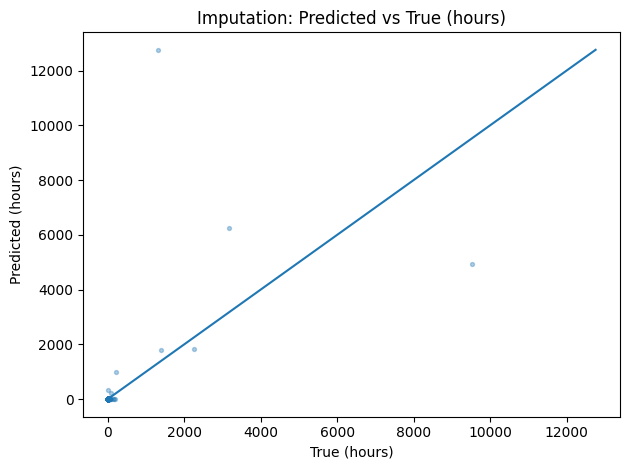

In [919]:
# scatter plot
plt.figure()
plt.scatter(y_true_hr, y_pred_hr, s=8, alpha=0.35)

# y = x reference line
lo = float(min(y_true_hr.min(), y_pred_hr.min()))
hi = float(max(y_true_hr.max(), y_pred_hr.max()))
plt.plot([lo, hi], [lo, hi])

plt.xlabel("True (hours)")
plt.ylabel("Predicted (hours)")
plt.title("Imputation: Predicted vs True (hours)")
plt.tight_layout()
plt.show()

Kept points: 156 / 170


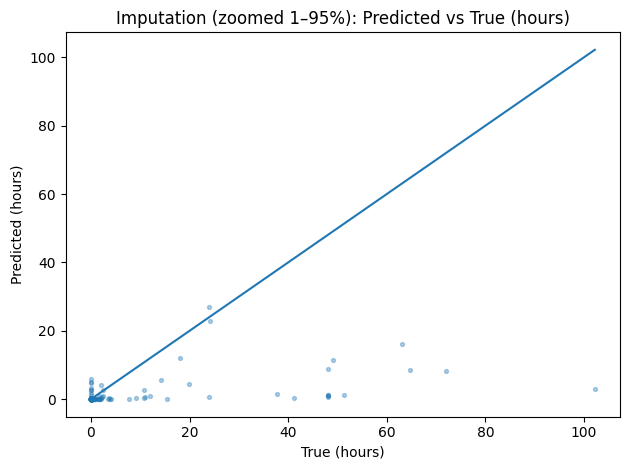

In [920]:
# keep only points within the central range on BOTH axes
lo_t, hi_t = np.nanpercentile(y_true_hr, [1, 95])
lo_p, hi_p = np.nanpercentile(y_pred_hr, [1, 95])

m = (
    (y_true_hr >= lo_t) & (y_true_hr <= hi_t) &
    (y_pred_hr >= lo_p) & (y_pred_hr <= hi_p)
)

print("Kept points:", int(m.sum()), "/", len(y_true_hr))

plt.figure()
plt.scatter(y_true_hr[m], y_pred_hr[m], s=8, alpha=0.35)

lo = float(min(y_true_hr[m].min(), y_pred_hr[m].min()))
hi = float(max(y_true_hr[m].max(), y_pred_hr[m].max()))
plt.plot([lo, hi], [lo, hi])

plt.xlabel("True (hours)")
plt.ylabel("Predicted (hours)")
plt.title("Imputation (zoomed 1–95%): Predicted vs True (hours)")
plt.tight_layout()
plt.show()

In [921]:
pred = saits.predict(test_set=dataset_for_IMPU_full)


In [922]:
target_col = "processing_duration_sec_log"
t_idx = FEATURE_COLS.index(target_col)

# SAITS output
full_imp = pred["imputation"]  # (N_cases, T, D)

# mask: missing in X_hat, NOT artificially masked, NOT padding
mask_real_missing_target = (
    (full_mm[:, :, t_idx] == 0) &     # missing in X_hat
    (full_im[:, :, t_idx] == 0) &     # NOT artificial
    (full_pm == 1)                    # not padding
)

ii, tt = np.where(mask_real_missing_target)

df_imp = pd.DataFrame({
    "case_id": full_case_ids[ii],
    "case_event_idx": full_ids[ii, tt],                 # <- this is the join key
    "imputed_scaled_log": full_imp[ii, tt, t_idx],       # <- still scaled+log space
})

# safety
df_imp = df_imp[df_imp["case_event_idx"] >= 0].copy()
df_imp["case_event_idx"] = df_imp["case_event_idx"].astype(int)


In [923]:
# where in the scaler vector is the target?
scaler_idx = SCALE_COLS.index(target_col)

mu = float(sc.loc[target_feature, "mean"])
sd = float(sc.loc[target_feature, "scale"])

# back to log space
df_imp["imputed_log"] = df_imp["imputed_scaled_log"] * sd + mu

# back to seconds (undo log1p)
df_imp["imputed_sec"] = np.expm1(df_imp["imputed_log"]).clip(lower=0)

In [924]:
df_out = df_missing.copy()
df_out["case_event_idx"] = df_out["case_event_idx"].astype(int)

df_out = df_out.merge(
    df_imp[["case_id", "case_event_idx", "imputed_sec"]],
    on=["case_id", "case_event_idx"],
    how="left",
)

df_out["complete_date"] = pd.to_datetime(df_out["complete_date"], errors="coerce")
df_out["start_date"]   = pd.to_datetime(df_out["start_date"], errors="coerce")

m = df_out["start_date"].isna() & df_out["complete_date"].notna() & df_out["imputed_sec"].notna()
df_out.loc[m, "start_date"] = df_out.loc[m, "complete_date"] - pd.to_timedelta(df_out.loc[m, "imputed_sec"], unit="s")

df_out = df_out.drop(columns=["imputed_sec"])
df_out.to_csv("missing_started_filled.csv", index=False)


In [925]:
print("Imputed rows to merge:", len(df_imp))
print("Unique join keys in df_imp:", df_imp[["case_id","case_event_idx"]].drop_duplicates().shape[0])

# how many got filled?
print("Filled count:", int(m.sum()))


Imputed rows to merge: 1838
Unique join keys in df_imp: 1838
Filled count: 1838


In [926]:
KEYS = ["case_id", "case_event_idx"]

eval_df = df_imp[KEYS + ["imputed_sec"]].merge(
    df_ground[KEYS + ["processing_duration_sec"]],
    on=KEYS,
    how="inner",
)

# cleanup
eval_df["imputed_sec"] = pd.to_numeric(eval_df["imputed_sec"], errors="coerce")
eval_df["processing_duration_sec"] = pd.to_numeric(eval_df["processing_duration_sec"], errors="coerce")

eval_df = eval_df.dropna(subset=["imputed_sec", "processing_duration_sec"]).copy()
eval_df["imputed_sec"] = eval_df["imputed_sec"].clip(lower=0)
eval_df["processing_duration_sec"] = eval_df["processing_duration_sec"].clip(lower=0)

print("Merged rows:", len(eval_df))


Merged rows: 1838


MAE (hours):   8.7579
RMSE (hours):  26.4901
MedAE (hours): 0.1584
R2:            -0.4121


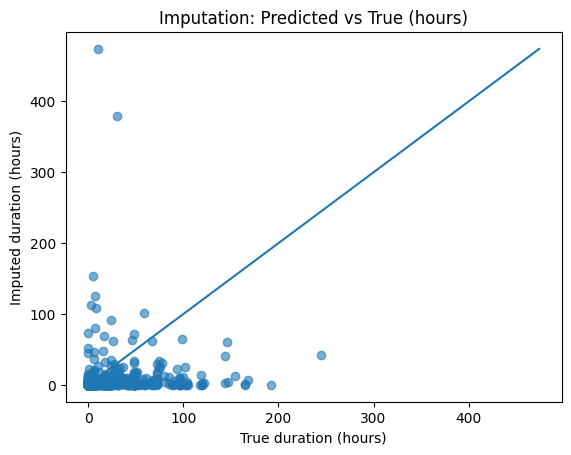

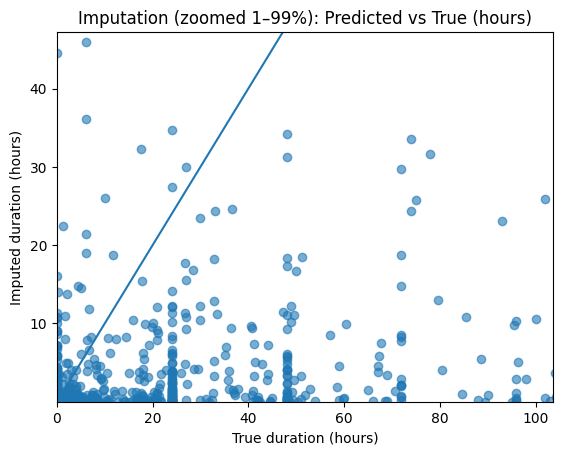

In [927]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
import matplotlib.pyplot as plt

y_true_h = (eval_df["processing_duration_sec"].to_numpy() / 3600.0)
y_pred_h = (eval_df["imputed_sec"].to_numpy() / 3600.0)

mae   = mean_absolute_error(y_true_h, y_pred_h)
rmse  = np.sqrt(mean_squared_error(y_true_h, y_pred_h))
medae = median_absolute_error(y_true_h, y_pred_h)
r2    = r2_score(y_true_h, y_pred_h)

print(f"MAE (hours):   {mae:.4f}")
print(f"RMSE (hours):  {rmse:.4f}")
print(f"MedAE (hours): {medae:.4f}")
print(f"R2:            {r2:.4f}")

# Full scatter
plt.figure()
plt.scatter(y_true_h, y_pred_h, alpha=0.6)
mx = max(np.max(y_true_h), np.max(y_pred_h))
plt.plot([0, mx], [0, mx])
plt.xlabel("True duration (hours)")
plt.ylabel("Imputed duration (hours)")
plt.title("Imputation: Predicted vs True (hours)")
plt.show()

# Zoomed scatter (1–99%)
x1, x99 = np.percentile(y_true_h, [1, 99])
y1, y99 = np.percentile(y_pred_h, [1, 99])

plt.figure()
plt.scatter(y_true_h, y_pred_h, alpha=0.6)
mx = max(x99, y99)
plt.plot([0, mx], [0, mx])
plt.xlim(x1, x99)
plt.ylim(y1, y99)
plt.xlabel("True duration (hours)")
plt.ylabel("Imputed duration (hours)")
plt.title("Imputation (zoomed 1–99%): Predicted vs True (hours)")
plt.show()
